# Diseño de Sistemas de Producción - Escenario 03
Este cuaderno consolida el análisis de productividad y la optimización logística del **Escenario 03**.
Se divide en las siguientes fases paso a paso, incluyendo tablas y gráficos ilustrativos.


In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog
from math import radians, cos, sin, asin, sqrt
import os
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = r"data\Escenario_03"
warmup_days = 60
warmup_hours = warmup_days * 24


## Justificación del Período de Calentamiento (Warm-up)
Para asegurar que nuestras métricas reflejen el comportamiento real a largo plazo del aserradero, debemos determinar el punto en el que el sistema alcanza su **estado estacionario** (dejando atrás la fase transitoria "vacía y ociosa" inicial).

El siguiente gráfico del inventario en `stock_aserrado` demuestra que la fase transitoria dura aprox. 60 días. A partir del Día 60 (línea roja), el nivel de inventario detiene su crecimiento y comienza a oscilar en torno a su tope, confirmando el estado estacionario.


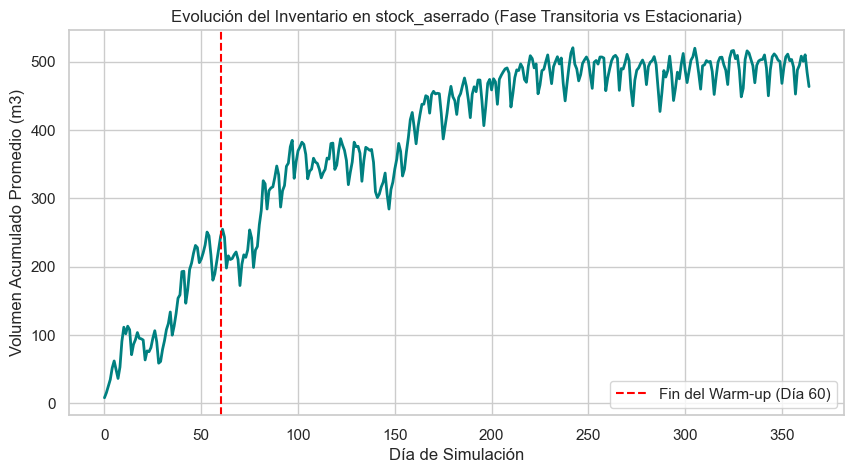

In [3]:
daily_wip_all = pd.read_csv(os.path.join(data_dir, "daily_wip.csv"))
stock_aserrado_wip = daily_wip_all[daily_wip_all['buffer'] == 'stock_aserrado'].groupby('day')['level_m3_mean'].mean().reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=stock_aserrado_wip, x='day', y='level_m3_mean', linewidth=2, color='teal')
plt.axvline(x=60, color='red', linestyle='--', label='Fin del Warm-up (Día 60)')
plt.title('Evolución del Inventario en stock_aserrado (Fase Transitoria vs Estacionaria)')
plt.xlabel('Día de Simulación')
plt.ylabel('Volumen Acumulado Promedio (m3)')
plt.legend()
plt.show()


## 1. Caracterización de Flujos
Filtramos los datos excluyendo el período de calentamiento (60 días) y calculamos los promedios de entrada de materia prima y salida de productos terminados por réplica.


In [4]:
# Carga de datos
calendar_df = pd.read_csv(os.path.join(data_dir, "calendar.csv"))
eval_hours = (calendar_df['day'].max() * 24 + 24) - warmup_hours

log_arrivals = pd.read_csv(os.path.join(data_dir, "log_arrivals.csv"))
log_arrivals_valid = log_arrivals[log_arrivals['arrival_time_h'] > warmup_hours]
total_in = log_arrivals_valid['volume_m3'].sum()

product_outputs = pd.read_csv(os.path.join(data_dir, "product_outputs.csv"))
product_outputs_valid = product_outputs[product_outputs['exit_time_h'] > warmup_hours]
total_out = product_outputs_valid['volume_m3'].sum()

num_replications = product_outputs['replication'].nunique()

promedio_entrada = total_in / num_replications
promedio_salida = total_out / num_replications
promedio_por_producto = (product_outputs_valid.groupby('product')['volume_m3'].sum() / num_replications).reset_index()

# Mostrar Resultados en Tabla
df_flujos = pd.DataFrame({
    'Métrica': ['Total Trozos (Input)', 'Total Prod. Terminados (Output)'],
    'Volumen (m3)': [promedio_entrada, promedio_salida],
    'Tasa (m3/hora)': [promedio_entrada / eval_hours, promedio_salida / eval_hours]
})
display(df_flujos.style.format({'Volumen (m3)': '{:,.2f}', 'Tasa (m3/hora)': '{:,.2f}'}))

# Mostrar producción por producto
promedio_por_producto['Tasa (m3/hora)'] = promedio_por_producto['volume_m3'] / eval_hours
df_prod = promedio_por_producto.rename(columns={'product': 'Producto', 'volume_m3': 'Volumen (m3)'})
display(df_prod.style.format({'Volumen (m3)': '{:,.2f}', 'Tasa (m3/hora)': '{:,.2f}'}).background_gradient(cmap='Greens'))


,Métrica,Volumen (m3),Tasa (m3/hora)
0,Total Trozos (Input),"55,235.55",7.55
1,Total Prod. Terminados (Output),"24,970.93",3.41


,Producto,Volumen (m3),Tasa (m3/hora)
0,P1,"8,463.70",1.16
1,P2,"10,788.81",1.47
2,P3,"5,718.41",0.78


## 2. Métricas de Desempeño (KPIs) por Estación
Analizamos el estado de las máquinas para calcular su **Utilización** y **Disponibilidad**. Aquí identificaremos claramente nuestro cuello de botella.


state,station,Utilization,Availability
0,aserradero,55.04%,98.95%
1,bano,8.17%,99.95%
2,drymill,32.78%,99.49%
3,impregnado,7.93%,99.88%
4,secado,93.05%,93.52%


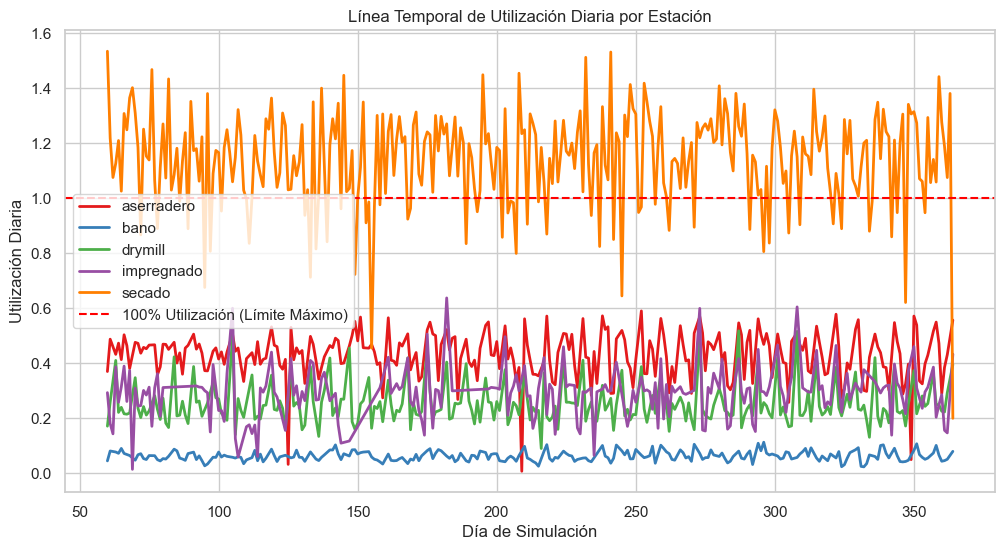

In [5]:
station_events = pd.read_csv(os.path.join(data_dir, "station_events.csv"))
se_valid = station_events[station_events['end_time_h'] > warmup_hours].copy()
se_valid['start_time_h'] = np.maximum(se_valid['start_time_h'], warmup_hours)
se_valid['duration'] = se_valid['end_time_h'] - se_valid['start_time_h']

state_durations = se_valid.groupby(['replication', 'station', 'state'])['duration'].sum().reset_index()

pivot_states = state_durations.pivot_table(index=['replication', 'station'], columns='state', values='duration', fill_value=0).reset_index()

if 'OFF_SHIFT' in pivot_states.columns:
    pivot_states['Operating_Time'] = eval_hours - pivot_states['OFF_SHIFT']
else:
    pivot_states['Operating_Time'] = eval_hours

if 'DOWN' not in pivot_states.columns: pivot_states['DOWN'] = 0
if 'BUSY' not in pivot_states.columns: pivot_states['BUSY'] = 0

pivot_states['Utilization'] = pivot_states['BUSY'] / pivot_states['Operating_Time']
pivot_states['Availability'] = (pivot_states['Operating_Time'] - pivot_states['DOWN']) / pivot_states['Operating_Time']

mean_kpis = pivot_states.groupby('station')[['Utilization', 'Availability']].mean().reset_index()

display(mean_kpis.style.format({'Utilization': '{:.2%}', 'Availability': '{:.2%}'}).background_gradient(cmap='Reds', subset=['Utilization']))

# Calcular utilización diaria (línea temporal)
se_valid['day'] = (se_valid['start_time_h'] // 24).astype(int)
# Sumar duraciones BUSY por día, réplica y estación
daily_busy = se_valid[se_valid['state'] == 'BUSY'].groupby(['replication', 'station', 'day'])['duration'].sum().reset_index()
# Suponiendo 24 horas por día operativo (simplificación para la tendencia)
daily_busy['Daily_Utilization'] = daily_busy['duration'] / 24

# Gráfico de Línea Temporal
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_busy, x='day', y='Daily_Utilization', hue='station', errorbar=None, linewidth=2, palette='Set1')
plt.title('Línea Temporal de Utilización Diaria por Estación')
plt.xlabel('Día de Simulación')
plt.ylabel('Utilización Diaria')
plt.axhline(1.0, color='red', linestyle='--', label='100% Utilización (Límite Máximo)')
plt.legend()
plt.show()


## 3. Tiempos de Ciclo Promedio
Calculamos cuánto tiempo le toma a cada máquina procesar un lote desde que entra hasta que sale. Esto refuerza la identificación del cuello de botella.


In [6]:
batches = pd.read_csv(os.path.join(data_dir, "batches.csv"))
batches_valid = batches[batches['start_process_time_h'] > warmup_hours].copy()

batches_valid['cycle_time'] = batches_valid['end_process_time_h'] - batches_valid['start_process_time_h']
mean_cycle_time = batches_valid.groupby('station')['cycle_time'].mean().reset_index()
mean_cycle_time.rename(columns={'station': 'Estación', 'cycle_time': 'Tiempo de Ciclo (Horas)'}, inplace=True)

display(mean_cycle_time.style.format({'Tiempo de Ciclo (Horas)': '{:.2f}'}).background_gradient(cmap='Purples'))


,Estación,Tiempo de Ciclo (Horas)
0,aserradero,1.45
1,bano,0.57
2,drymill,2.96
3,impregnado,3.56
4,secado,27.79


## 4. Análisis de Inventarios (WIP) y Cuello de Botella
Vamos a observar cómo se acumula el material antes de cada estación. Un nivel de inventario masivo antes de una máquina es el indicador definitivo de un cuello de botella.


In [7]:
daily_wip = pd.read_csv(os.path.join(data_dir, "daily_wip.csv"))
daily_wip_valid = daily_wip[daily_wip['day'] > warmup_days]

buffer_stats = daily_wip_valid.groupby('buffer').agg(
    WIP_Promedio=('level_m3_mean', 'mean'),
    WIP_Maximo=('level_m3_max', 'max')
).reset_index()

display(buffer_stats.style.format({'WIP_Promedio': '{:.2f}', 'WIP_Maximo': '{:.2f}'}).background_gradient(cmap='Oranges'))


,buffer,WIP_Promedio,WIP_Maximo
0,log_yard,655.07,2830.13
1,stock_aserrado,427.92,535.00
2,stock_drymill,2.77,65.89
3,stock_seco,16.92,155.20


## 5. Propuesta de Mejora Cuantificada
Con la evidencia anterior, la mejora propuesta es agregar capacidad adicional al proceso de **Secado**, que aparece como el cuello de botella de la línea. Esta evaluación se construye como un escenario hipotetico: no corresponde a una nueva simulación, sino a una estimación usando las tasas observadas del sistema.

La estimación considera las horas en que el Aserradero estuvo bloqueado, su tasa observada de procesamiento, el mix de productos y el rendimiento histórico hasta producto terminado.


In [8]:
products_for_improvement = ['P1', 'P2', 'P3']

if 'BLOCKED' not in pivot_states.columns:
    pivot_states['BLOCKED'] = 0

aserradero_state_rows = pivot_states[pivot_states['station'] == 'aserradero']
aserradero_blocked_h = aserradero_state_rows['BLOCKED'].sum()
aserradero_busy_h = aserradero_state_rows['BUSY'].sum()
aserradero_batches = batches_valid[batches_valid['station'] == 'aserradero'].copy()
aserradero_output_total = aserradero_batches['volume_out_m3'].sum()

if aserradero_busy_h > 0 and aserradero_output_total > 0:
    aserradero_rate_m3_h = aserradero_output_total / aserradero_busy_h
    extra_aserradero_output_total = aserradero_blocked_h * aserradero_rate_m3_h

    aserradero_output_by_product = (
        aserradero_batches.groupby('product')['volume_out_m3']
        .sum()
        .reindex(products_for_improvement, fill_value=0)
    )
    product_mix_aserradero = aserradero_output_by_product / aserradero_output_total

    finished_output_by_product = (
        product_outputs_valid.groupby('product')['volume_m3']
        .sum()
        .reindex(products_for_improvement, fill_value=0)
    )
    terminal_yield = (
        finished_output_by_product / aserradero_output_by_product.replace(0, np.nan)
    ).fillna(0)

    extra_finished_by_product = extra_aserradero_output_total * product_mix_aserradero * terminal_yield
    current_finished_avg = finished_output_by_product / num_replications
    extra_finished_avg = extra_finished_by_product / num_replications
    scenario_finished_avg = current_finished_avg + extra_finished_avg
    scenario_production = scenario_finished_avg.to_dict()

    improvement_summary = pd.DataFrame({
        'Producto': products_for_improvement,
        'Producción actual (m3)': current_finished_avg.values,
        'Producción adicional estimada (m3)': extra_finished_avg.values,
        'Producción con mejora (m3)': scenario_finished_avg.values,
    })

    improvement_total = pd.DataFrame({
        'Producto': ['Total'],
        'Producción actual (m3)': [current_finished_avg.sum()],
        'Producción adicional estimada (m3)': [extra_finished_avg.sum()],
        'Producción con mejora (m3)': [scenario_finished_avg.sum()],
    })
    improvement_table = pd.concat([improvement_summary, improvement_total], ignore_index=True)

    total_current = current_finished_avg.sum()
    total_extra = extra_finished_avg.sum()
    total_scenario = scenario_finished_avg.sum()
    total_increase_pct = (total_extra / total_current) * 100 if total_current > 0 else 0

    secado_output_total = batches_valid[batches_valid['station'] == 'secado']['volume_out_m3'].sum()
    extra_material_to_secado = extra_aserradero_output_total * product_mix_aserradero[['P2', 'P3']].sum()
    secado_extra_capacity_use = (
        (extra_material_to_secado / secado_output_total) * 100
        if secado_output_total > 0 else 0
    )

    display(improvement_table.style.format({
        'Producción actual (m3)': '{:,.2f}',
        'Producción adicional estimada (m3)': '{:,.2f}',
        'Producción con mejora (m3)': '{:,.2f}',
    }).background_gradient(cmap='Blues', subset=['Producción adicional estimada (m3)', 'Producción con mejora (m3)']))

    improvement_kpis = pd.DataFrame({
        'Indicador': [
            'Horas bloqueadas del Aserradero por réplica',
            'Tasa observada del Aserradero en BUSY',
            'Aumento total estimado por réplica',
            'Aumento porcentual estimado',
            'Uso estimado de una capacidad adicional de Secado'
        ],
        'Valor': [
            aserradero_blocked_h / num_replications,
            aserradero_rate_m3_h,
            total_extra,
            total_increase_pct,
            secado_extra_capacity_use
        ],
        'Unidad': ['h', 'm3/h', 'm3', '%', '%']
    })

    display(improvement_kpis.style.format({'Valor': '{:,.2f}'}))
else:
    print('No hay datos suficientes para estimar la mejora de capacidad de Secado.')


,Producto,Producción actual (m3),Producción adicional estimada (m3),Producción con mejora (m3)
0,P1,"8,463.70","3,981.69","12,445.39"
1,P2,"10,788.81","5,075.52","15,864.34"
2,P3,"5,718.41","2,690.19","8,408.60"
3,Total,"24,970.93","11,747.40","36,718.33"


,Indicador,Valor,Unidad
0,Horas bloqueadas del Aserradero por réplica,"1,260.68",h
1,Tasa observada del Aserradero en BUSY,9.99,m3/h
2,Aumento total estimado por réplica,"11,747.40",m3
3,Aumento porcentual estimado,47.04,%
4,Uso estimado de una capacidad adicional de Secado,49.34,%


## 6. Optimización Logística (Problema de Transporte)
Formulamos la red de distribución como un **Problema de Transporte** (un caso de Flujo de Costo Mínimo o MCNF). 
Asignaremos el flujo óptimo desde el nodo de oferta (Aserradero Mulchén) hacia los nodos de demanda (puertos y plantas), minimizando los costos de los arcos. 
La métrica de distancia de red se obtiene de forma real vía OSRM (con Haversine como respaldo).


In [9]:
import requests

def get_driving_distance(lat1, lon1, lat2, lon2):
    # Uso de la API pública de OSRM (Open Source Routing Machine) para calcular distancia REAL por carretera
    try:
        url = f"http://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}?overview=false"
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()['routes'][0]['distance'] / 1000.0 # m a km
    except:
        pass
    
    # Fallback: Fórmula de Haversine * Factor de Ruteo 1.3
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1) * cos(lat2) * sin((lon2-lon1)/2)**2
    return 2 * asin(sqrt(a)) * 6371 * 1.3

nodes = {
    'Mulchen': (-37.7165, -72.2412),
    'P_Coronel': (-37.0298, -73.1432),
    'P_San_Vicente': (-36.7214, -73.1311),
    'P_Lirquen': (-36.7095, -72.9764),
    'R_Coronel': (-37.0253, -73.1345),
    'R_Los_Angeles': (-37.2618, -72.6975),
    'Ply_Collipulli': (-37.9547, -72.4190)
}
dests = ['P_Coronel', 'P_San_Vicente', 'P_Lirquen', 'R_Coronel', 'R_Los_Angeles', 'Ply_Collipulli']

print("Calculando distancias reales por carretera (vía OSRM API)...")
distances = {}
for d in dests:
    distances[d] = get_driving_distance(nodes['Mulchen'][0], nodes['Mulchen'][1], nodes[d][0], nodes[d][1])
    print(f" - Mulchén a {d}: {distances[d]:.1f} km")

products = ['P1', 'P2', 'P3']
prod_dict = promedio_por_producto.set_index('product')['volume_m3'].to_dict()

bounds_dict = {
    'P1': {'P_Coronel': (1200, 12000), 'R_Coronel': (1500, 8000), 'R_Los_Angeles': (1300, 6000)},
    'P2': {'P_Lirquen': (1500, 8000), 'P_San_Vicente': (1500, 8000), 'R_Los_Angeles': (1500, 5000), 'Ply_Collipulli': (1500, 5000)},
    'P3': {'P_Coronel': (1200, 10000), 'P_San_Vicente': (800, 12000), 'Ply_Collipulli': (1000, 4000)}
}

variables, bounds, cost_coefficients = [], [], []

for p in products:
    for d in dests:
        variables.append((p, d))
        cost_coefficients.append(distances[d] * 100) 
        bounds.append(bounds_dict[p].get(d, (0, 0)))

A_eq, b_eq = np.zeros((3, 18)), np.zeros(3)
for i, p in enumerate(products):
    b_eq[i] = prod_dict[p]
    for j, var in enumerate(variables):
        if var[0] == p: A_eq[i, j] = 1

res = linprog(cost_coefficients, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if res.success:
    resultados = []
    for j, var in enumerate(variables):
        if res.x[j] > 0.01:
            resultados.append({
                'Producto': var[0], 'Destino': var[1], 'Volumen (m3)': res.x[j],
                'Distancia (km)': distances[var[1]], 'Costo (CLP)': res.x[j] * 100 * distances[var[1]]
            })
    df_opt = pd.DataFrame(resultados)
    
    print(f"COSTO LOGÍSTICO TOTAL MÍNIMO: $ {res.fun:,.0f} CLP")
    display(df_opt.style.format({'Volumen (m3)': '{:,.2f}', 'Distancia (km)': '{:.1f}', 'Costo (CLP)': '$ {:,.0f}'}))
else:
    print("Error:", res.message)


Calculando distancias reales por carretera (vía OSRM API)...
 - Mulchén a P_Coronel: 145.7 km
 - Mulchén a P_San_Vicente: 174.9 km
 - Mulchén a P_Lirquen: 172.6 km
 - Mulchén a R_Coronel: 144.5 km
 - Mulchén a R_Los_Angeles: 76.4 km
 - Mulchén a Ply_Collipulli: 38.9 km
COSTO LOGÍSTICO TOTAL MÍNIMO: $ 222,015,438 CLP


,Producto,Destino,Volumen (m3),Distancia (km),Costo (CLP)
0,P1,P_Coronel,"1,200.00",145.7,"$ 17,483,592"
1,P1,R_Coronel,"1,500.00",144.5,"$ 21,672,285"
2,P1,R_Los_Angeles,"5,763.70",76.4,"$ 44,048,956"
3,P2,P_San_Vicente,"1,500.00",174.9,"$ 26,227,665"
4,P2,P_Lirquen,"1,500.00",172.6,"$ 25,889,355"
5,P2,R_Los_Angeles,"2,788.81",76.4,"$ 21,313,461"
6,P2,Ply_Collipulli,"5,000.00",38.9,"$ 19,446,450"
7,P3,P_Coronel,"1,200.00",145.7,"$ 17,483,592"
8,P3,P_San_Vicente,800.00,174.9,"$ 13,988,088"
9,P3,Ply_Collipulli,"3,718.41",38.9,"$ 14,461,994"


## 7. Comparación con Heurísticas de Referencia
Para evaluar la calidad del plan logístico óptimo, se comparan dos reglas simples de asignación. La primera cumple los mínimos y luego envía el excedente al destino factible más cercano. La segunda cumple los mínimos y reparte el excedente proporcionalmente según la capacidad remanente de cada destino.

La heurística proporcional se incluye como benchmark operativo de baja complejidad: no requiere resolver un modelo de optimización y representa una política simple de reparto que no prioriza explícitamente la distancia.


In [10]:
def calcular_costo_plan(plan_df):
    return (plan_df['Volumen (m3)'] * plan_df['Distancia (km)'] * 100).sum()


def construir_plan_minimos_y_cercano(prod_dict, bounds_dict, distances):
    asignaciones = []

    for p in products:
        product_supply = prod_dict[p]
        product_bounds = bounds_dict[p]
        min_required = sum(lb for lb, _ in product_bounds.values())
        max_capacity = sum(ub for _, ub in product_bounds.values())

        if product_supply < min_required or product_supply > max_capacity:
            raise ValueError(f'Producción de {p} fuera de rango factible.')

        product_allocation = {d: lb for d, (lb, _) in product_bounds.items()}
        remaining_volume = product_supply - min_required

        for d in sorted(product_bounds, key=lambda dest: distances[dest]):
            _, upper_bound = product_bounds[d]
            available_capacity = upper_bound - product_allocation[d]
            assigned_volume = min(remaining_volume, available_capacity)
            product_allocation[d] += assigned_volume
            remaining_volume -= assigned_volume
            if remaining_volume <= 1e-6:
                break

        for d, volume in product_allocation.items():
            asignaciones.append({
                'Producto': p,
                'Destino': d,
                'Volumen (m3)': volume,
                'Distancia (km)': distances[d],
                'Costo (CLP)': volume * distances[d] * 100
            })

    return pd.DataFrame(asignaciones)


def construir_plan_proporcional(prod_dict, bounds_dict, distances):
    asignaciones = []

    for p in products:
        product_supply = prod_dict[p]
        product_bounds = bounds_dict[p]
        min_required = sum(lb for lb, _ in product_bounds.values())
        remaining_volume = product_supply - min_required
        remaining_capacities = {
            d: upper_bound - lower_bound
            for d, (lower_bound, upper_bound) in product_bounds.items()
        }
        total_remaining_capacity = sum(remaining_capacities.values())

        if remaining_volume < -1e-6 or remaining_volume > total_remaining_capacity + 1e-6:
            raise ValueError(f'Producción de {p} fuera de rango factible.')

        for d, (lower_bound, _) in product_bounds.items():
            proportional_extra = (
                remaining_volume * remaining_capacities[d] / total_remaining_capacity
                if total_remaining_capacity > 0 else 0
            )
            volume = lower_bound + proportional_extra
            asignaciones.append({
                'Producto': p,
                'Destino': d,
                'Volumen (m3)': volume,
                'Distancia (km)': distances[d],
                'Costo (CLP)': volume * distances[d] * 100
            })

    return pd.DataFrame(asignaciones)


if res.success:
    optimal_cost = res.fun
    heuristic_nearest_plan = construir_plan_minimos_y_cercano(prod_dict, bounds_dict, distances)
    heuristic_proportional_plan = construir_plan_proporcional(prod_dict, bounds_dict, distances)

    heuristic_nearest_cost = calcular_costo_plan(heuristic_nearest_plan)
    heuristic_proportional_cost = calcular_costo_plan(heuristic_proportional_plan)

    comparison_df = pd.DataFrame({
        'Método': ['Modelo óptimo', 'Heurística destino más cercano', 'Heurística proporcional'],
        'Costo total (CLP)': [optimal_cost, heuristic_nearest_cost, heuristic_proportional_cost],
        'Diferencia vs. óptimo (CLP)': [0, heuristic_nearest_cost - optimal_cost, heuristic_proportional_cost - optimal_cost],
        'Brecha vs. óptimo (%)': [0, (heuristic_nearest_cost - optimal_cost) / optimal_cost * 100, (heuristic_proportional_cost - optimal_cost) / optimal_cost * 100]
    })

    display(comparison_df.style.format({
        'Costo total (CLP)': '$ {:,.0f}',
        'Diferencia vs. óptimo (CLP)': '$ {:,.0f}',
        'Brecha vs. óptimo (%)': '{:.2f}%'
    }).background_gradient(cmap='Reds', subset=['Brecha vs. óptimo (%)']))

    display(heuristic_proportional_plan.style.format({
        'Volumen (m3)': '{:,.2f}',
        'Distancia (km)': '{:.1f}',
        'Costo (CLP)': '$ {:,.0f}'
    }))
else:
    print('No se construyen heurísticas porque el modelo óptimo no encontró solución factible.')


,Método,Costo total (CLP),Diferencia vs. óptimo (CLP),Brecha vs. óptimo (%)
0,Modelo óptimo,"$ 222,015,438",$ 0,0.00%
1,Heurística destino más cercano,"$ 222,015,438",$ 0,0.00%
2,Heurística proporcional,"$ 315,553,530","$ 93,538,092",42.13%


,Producto,Destino,Volumen (m3),Distancia (km),Costo (CLP)
0,P1,P_Coronel,"3,391.27",145.7,"$ 49,409,658"
1,P1,R_Coronel,"2,818.82",144.5,"$ 40,726,850"
2,P1,R_Los_Angeles,"2,253.61",76.4,"$ 17,223,158"
3,P2,P_Lirquen,"3,056.36",172.6,"$ 52,751,542"
4,P2,P_San_Vicente,"3,056.36",174.9,"$ 53,440,875"
5,P2,R_Los_Angeles,"2,338.04",76.4,"$ 17,868,444"
6,P2,Ply_Collipulli,"2,338.04",38.9,"$ 9,093,326"
7,P3,P_Coronel,"2,240.09",145.7,"$ 32,637,338"
8,P3,P_San_Vicente,"2,123.75",174.9,"$ 37,134,001"
9,P3,Ply_Collipulli,"1,354.58",38.9,"$ 5,268,338"
